In [30]:
import mcmr

In [31]:
x_world, y_world = 64, 64

x_grid = []
y_grid = []
for i in range(8, 64, 8):
    x_grid.append(i)
    y_grid.append(i)

material_matrix = [["Fe"] * 8 for _ in range(8)]

sources = [[0] * 8 for _ in range(8)]

In [32]:
world = mcmr.World(
    x_world=x_world, y_world=y_world,
    x_grid=x_grid, y_grid=y_grid,
    material_matrix=material_matrix,
    sources=sources,
    bc_top="reflective",
    bc_bot="reflective",
    bc_left="reflective",
    bc_right="reflective",
)

In [33]:
world.add_circles(
    radius_matrix=[[2.5] * 8 for _ in range(8)],
    material_matrix=[["C"] * 8 for _ in range(8)],
    source_matrix=[[1] * 8 for _ in range(8)],
)

In [34]:
sim = world.run(N=1000, max_save=100)

              MCMR Simulation Engine               
 Total Particle   : 1000
running...
Progress: [1000/1000] (100%)
 Simulation End in 2.8485 seconds.



In [35]:
t = sim.get_tally()
print(t.absorp_by_material)

{'C': 207, 'Fe': 793}


In [36]:
world.export("mcmr_world.xml")

'mcmr_world.xml'

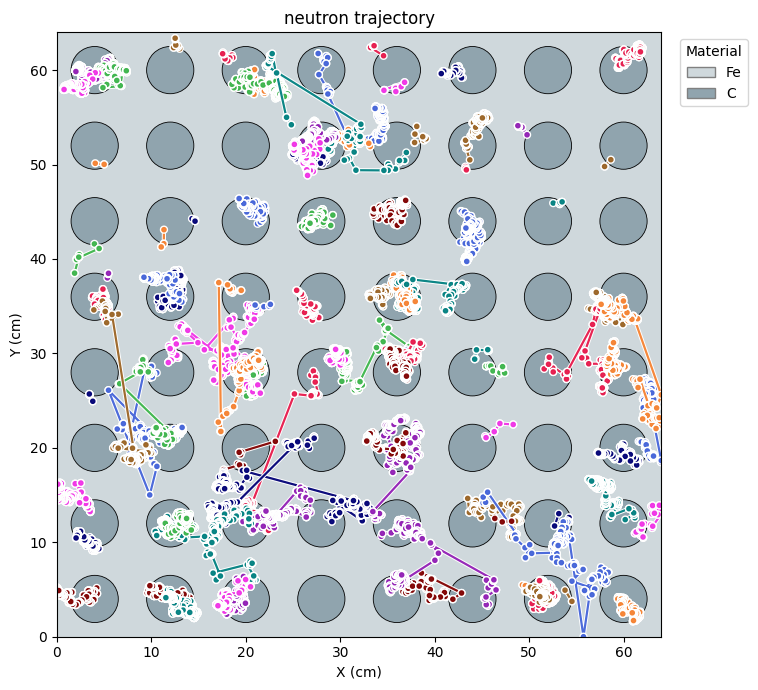

In [37]:
# run() tidak lagi otomatis menulis file hasil ke disk (lihat perbaikan bug 11.a) --
# tulis sendiri, dengan nama file pilihan sendiri:
sim.export_xml("mcmr_results.xml")

plotter = mcmr.ResultsPlotter("mcmr_results.xml")
plotter.plot_trajectories(world_xml="mcmr_world.xml")